**Imports**

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("beard_model_ready_features.csv")
print(f"Loaded: {df.shape[0]} compounds")

Loaded: 6878 compounds


**Compute Bemis-Murcko scaffolds for every compound**

In [2]:
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

df["scaffold"] = df["canonical_smi"].apply(get_scaffold)

print(f"Compounds with valid scaffold: {df['scaffold'].notna().sum()} / {df.shape[0]}")
print(f"Unique scaffolds: {df['scaffold'].nunique()}")
print(f"Compounds with EMPTY scaffold (fully acyclic, no rings): {(df['scaffold'] == '').sum()}")

[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors
[09:21:37] WARNING: not removing hydrogen atom without neighbors


[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not removing hydrogen atom without neighbors
[09:21:39] WARNING: not r

Compounds with valid scaffold: 6878 / 6878
Unique scaffolds: 3247
Compounds with EMPTY scaffold (fully acyclic, no rings): 397


**Group compounds by scaffold and check the distribution — this tells us what kind of split we're actually working with**

In [3]:
scaffold_groups = df.groupby("scaffold").size().sort_values(ascending=False)
print(f"Largest scaffold groups:")
print(scaffold_groups.head(10))
print(f"\nScaffolds with only 1 compound (singletons): {(scaffold_groups == 1).sum()} / {len(scaffold_groups)}")

Largest scaffold groups:
scaffold
                                                   397
c1ccccc1                                           372
O=c1ccc2ccccc2o1                                    42
c1ccncc1                                            39
c1ccc2ccccc2c1                                      37
O=C1c2ccccc2C(=O)c2ccccc21                          36
c1ccc(-c2nc3c(c4c2-c2ccccc2CC4)-c2ccccc2CC3)cc1     33
c1ccc(N=Nc2ccccc2)cc1                               29
c1ccc2c(c1)[nH]c1ccccc12                            29
c1ccc(N=Nc2nc3ccccc3s2)cc1                          27
dtype: int64

Scaffolds with only 1 compound (singletons): 2336 / 3247


**Build scaffold groups for splitting, handling the empty-scaffold case correctly**

In [4]:
df["scaffold_group"] = df["scaffold"]
empty_mask = df["scaffold"] == ""
df.loc[empty_mask, "scaffold_group"] = "acyclic_" + df.loc[empty_mask].index.astype(str)

print(f"Total distinct groups for splitting: {df['scaffold_group'].nunique()}")

Total distinct groups for splitting: 3643


**Perform the actual scaffold split — assign whole scaffold groups to train or test, never splitting a group across both**

In [5]:
from sklearn.model_selection import train_test_split as tts

unique_scaffolds = df["scaffold_group"].unique()
scaffold_train, scaffold_test = tts(unique_scaffolds, test_size=0.2, random_state=42)

train_mask = df["scaffold_group"].isin(scaffold_train)
test_mask = df["scaffold_group"].isin(scaffold_test)

print(f"Train: {train_mask.sum()} compounds ({df.loc[train_mask, 'scaffold_group'].nunique()} scaffolds)")
print(f"Test: {test_mask.sum()} compounds ({df.loc[test_mask, 'scaffold_group'].nunique()} scaffolds)")
print(f"Train/test ratio: {train_mask.sum() / (train_mask.sum() + test_mask.sum()):.2f}")

Train: 4963 compounds (2914 scaffolds)
Test: 1915 compounds (729 scaffolds)
Train/test ratio: 0.72


**Compute fingerprints for this split and fit the GP — same architecture as the primary model, so the comparison is a fair like-for-like**

In [6]:
def get_morgan_fp(smi, radius=2, n_bits=256):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_list = df["canonical_smi"].apply(get_morgan_fp)
fp_matrix = np.stack(fp_list.values)
fp_df_scaffold = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(256)])

X_scaffold = pd.concat([fp_df_scaffold, df[["LargestConjugatedSystemSize"]].reset_index(drop=True)], axis=1)
y_scaffold = df["lambda_max_exp_nm"].reset_index(drop=True)

X_train_scaf = X_scaffold[train_mask.values]
X_test_scaf = X_scaffold[test_mask.values]
y_train_scaf = y_scaffold[train_mask.values]
y_test_scaf = y_scaffold[test_mask.values]

print(f"Train: {X_train_scaf.shape}, Test: {X_test_scaf.shape}")

scaler_scaf = StandardScaler()
X_train_scaf_scaled = scaler_scaf.fit_transform(X_train_scaf)
X_test_scaf_scaled = scaler_scaf.transform(X_test_scaf)

kernel_scaf = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_scaffold = GaussianProcessRegressor(kernel=kernel_scaf, n_restarts_optimizer=2, random_state=42)

start = time.time()
print("Starting scaffold-split GP fit...")
gp_scaffold.fit(X_train_scaf_scaled, y_train_scaf)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_scaffold.kernel_)

y_pred_scaf, y_std_scaf = gp_scaffold.predict(X_test_scaf_scaled, return_std=True)
rmse_scaf = np.sqrt(mean_squared_error(y_test_scaf, y_pred_scaf))
r2_scaf = r2_score(y_test_scaf, y_pred_scaf)

print(f"GP, scaffold split (n_train={len(X_train_scaf)}): RMSE = {rmse_scaf:.2f} nm, R² = {r2_scaf:.3f}")
print(f"\nFor comparison, random split (Section 1.21):")
print(f"GP, random split (n_train=5502): RMSE = 92.15 nm, R² = 0.455")

joblib.dump(gp_scaffold, "gp_scaffold_model.joblib")
joblib.dump(scaler_scaf, "scaler_scaf.joblib")
print("Model saved.")

[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerator
[09:21:39] DEPRECATION WARNING: please use MorganGenerat

Train: (4963, 257), Test: (1915, 257)
Starting scaffold-split GP fit...


Done in 951.2 seconds.
170**2 * RBF(length_scale=16.8) + WhiteKernel(noise_level=4.81e+03)


GP, scaffold split (n_train=4963): RMSE = 105.93 nm, R² = 0.241

For comparison, random split (Section 1.21):
GP, random split (n_train=5502): RMSE = 92.15 nm, R² = 0.455


Model saved.


In [7]:
gp_scaf_residuals = y_test_scaf.values - y_pred_scaf
print(f"Scaffold-split GP mean bias: {gp_scaf_residuals.mean():.2f} nm")
print(f"Scaffold-split GP residual std: {gp_scaf_residuals.std():.2f} nm")

calib_scaf = np.corrcoef(y_std_scaf, np.abs(gp_scaf_residuals))[0, 1]
print(f"Calibration r (scaffold split): {calib_scaf:.3f}")

Scaffold-split GP mean bias: -10.74 nm
Scaffold-split GP residual std: 105.39 nm
Calibration r (scaffold split): -0.030


**Ridge on the scaffold split**

In [8]:
from sklearn.linear_model import RidgeCV

ridge_scaf = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
ridge_scaf.fit(X_train_scaf_scaled, y_train_scaf)

y_pred_ridge_scaf = ridge_scaf.predict(X_test_scaf_scaled)
rmse_ridge_scaf = np.sqrt(mean_squared_error(y_test_scaf, y_pred_ridge_scaf))
r2_ridge_scaf = r2_score(y_test_scaf, y_pred_ridge_scaf)

print(f"Ridge, scaffold split (n_train={len(X_train_scaf)}): RMSE = {rmse_ridge_scaf:.2f} nm, R² = {r2_ridge_scaf:.3f}, alpha = {ridge_scaf.alpha_}")

print(f"\nFull comparison:")
print(f"GP, scaffold split:    RMSE = 105.93 nm, R² = 0.241")
print(f"Ridge, scaffold split: RMSE = {rmse_ridge_scaf:.2f} nm, R² = {r2_ridge_scaf:.3f}")
print(f"\nFor reference (random split):")
print(f"GP, random split:    RMSE = 92.15 nm, R² = 0.455")
print(f"Ridge, random split: RMSE = 109.91 nm, R² = 0.225")

Ridge, scaffold split (n_train=4963): RMSE = 111.30 nm, R² = 0.162, alpha = 2000

Full comparison:
GP, scaffold split:    RMSE = 105.93 nm, R² = 0.241
Ridge, scaffold split: RMSE = 111.30 nm, R² = 0.162

For reference (random split):
GP, random split:    RMSE = 92.15 nm, R² = 0.455
Ridge, random split: RMSE = 109.91 nm, R² = 0.225


**Matched-size random-split GP control (n=4,963)**

In [9]:
X_train_matched, X_test_matched, y_train_matched, y_test_matched = tts(
    X_scaffold, y_scaffold, train_size=4963, random_state=42
)

print(f"Train: {X_train_matched.shape}, Test: {X_test_matched.shape}")

scaler_matched = StandardScaler()
X_train_matched_scaled = scaler_matched.fit_transform(X_train_matched)
X_test_matched_scaled = scaler_matched.transform(X_test_matched)

kernel_matched = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_matched_control = GaussianProcessRegressor(kernel=kernel_matched, n_restarts_optimizer=2, random_state=42)

start = time.time()
print("Starting matched-size random-split GP fit...")
gp_matched_control.fit(X_train_matched_scaled, y_train_matched)
print(f"Done in {time.time() - start:.1f} seconds.")

y_pred_matched, y_std_matched = gp_matched_control.predict(X_test_matched_scaled, return_std=True)
rmse_matched = np.sqrt(mean_squared_error(y_test_matched, y_pred_matched))
r2_matched = r2_score(y_test_matched, y_pred_matched)

print(f"GP, RANDOM split, matched size (n_train=4963): RMSE = {rmse_matched:.2f} nm, R² = {r2_matched:.3f}")

print(f"\nFull three-way comparison:")
print(f"GP, random split, n_train=5502 (original):  RMSE = 92.15 nm, R² = 0.455")
print(f"GP, random split, n_train=4963 (matched):    RMSE = {rmse_matched:.2f} nm, R² = {r2_matched:.3f}")
print(f"GP, scaffold split, n_train=4963:            RMSE = 105.93 nm, R² = 0.241")

joblib.dump(gp_matched_control, "gp_matched_control_model.joblib")
joblib.dump(scaler_matched, "scaler_matched.joblib")
print("Model saved.")

Train: (4963, 257), Test: (1915, 257)
Starting matched-size random-split GP fit...


Done in 1005.6 seconds.


GP, RANDOM split, matched size (n_train=4963): RMSE = 93.85 nm, R² = 0.438

Full three-way comparison:
GP, random split, n_train=5502 (original):  RMSE = 92.15 nm, R² = 0.455
GP, random split, n_train=4963 (matched):    RMSE = 93.85 nm, R² = 0.438
GP, scaffold split, n_train=4963:            RMSE = 105.93 nm, R² = 0.241
Model saved.


**TD-DFT — reconstruct and check genuine scaffold-split holdout status**

In [10]:
col_names = [
    "SMI", "lambda1_sTDA_nm", "F1_sTDA", "lambda1_TDDFT_nm", "F1_TDDFT",
    "lambda_max_exp_nm", "extinction", "solvent"
]
df_raw = pd.read_csv("paper_allDB.csv", header=None, skiprows=1, names=col_names)

df_tddft = df_raw[df_raw["lambda1_TDDFT_nm"].notna()].copy()
df_tddft["mol"] = df_tddft["SMI"].apply(Chem.MolFromSmiles)
df_tddft = df_tddft[df_tddft["mol"].notna()].copy()
df_tddft["canonical_smi"] = df_tddft["mol"].apply(Chem.MolToSmiles)

df_clean_final = pd.read_csv("beard_uvvis_cleaned.csv")
df_tddft = df_tddft[df_tddft["canonical_smi"].isin(df_clean_final["canonical_smi"])].copy()

# Check against SCAFFOLD split test set membership (df.loc[test_mask, "canonical_smi"])
scaffold_test_smis = set(df.loc[test_mask, "canonical_smi"])
tddft_smis = set(df_tddft["canonical_smi"])
tddft_scaffold_held_out = tddft_smis & scaffold_test_smis

print(f"TD-DFT compounds genuinely in SCAFFOLD test set: {len(tddft_scaffold_held_out)}")
print(f"(For reference, random-split TD-DFT holdout was: 36)")

TD-DFT compounds genuinely in SCAFFOLD test set: 28
(For reference, random-split TD-DFT holdout was: 36)


**sTDA — same check**

In [11]:
df_stda = df_raw[df_raw["lambda1_sTDA_nm"].notna()].copy()
df_stda["mol"] = df_stda["SMI"].apply(Chem.MolFromSmiles)
df_stda = df_stda[df_stda["mol"].notna()].copy()
df_stda["canonical_smi"] = df_stda["mol"].apply(Chem.MolToSmiles)
df_stda = df_stda[df_stda["canonical_smi"].isin(df_clean_final["canonical_smi"])].copy()

stda_smis = set(df_stda["canonical_smi"])
stda_scaffold_held_out = stda_smis & scaffold_test_smis

print(f"sTDA compounds genuinely in SCAFFOLD test set: {len(stda_scaffold_held_out)}")
print(f"(For reference, random-split sTDA holdout was: 1,011)")

sTDA compounds genuinely in SCAFFOLD test set: 1477
(For reference, random-split sTDA holdout was: 1,011)


**Evaluate GP (scaffold model) and TD-DFT on these 28 compounds**

In [12]:
eval_mask_tddft_scaf = df["canonical_smi"].isin(tddft_scaffold_held_out)

X_eval_tddft_scaf = pd.concat([
    fp_df_scaffold[eval_mask_tddft_scaf].reset_index(drop=True),
    df.loc[eval_mask_tddft_scaf, "LargestConjugatedSystemSize"].reset_index(drop=True)
], axis=1)

eval_tddft_scaf_smis = df.loc[eval_mask_tddft_scaf, "canonical_smi"].reset_index(drop=True)
y_true_tddft_scaf = df.loc[eval_mask_tddft_scaf, "lambda_max_exp_nm"].reset_index(drop=True)

X_eval_tddft_scaf_scaled = scaler_scaf.transform(X_eval_tddft_scaf)
y_pred_tddft_scaf_gp, y_std_tddft_scaf_gp = gp_scaffold.predict(X_eval_tddft_scaf_scaled, return_std=True)

rmse_gp_tddft_scaf = np.sqrt(mean_squared_error(y_true_tddft_scaf, y_pred_tddft_scaf_gp))
r2_gp_tddft_scaf = r2_score(y_true_tddft_scaf, y_pred_tddft_scaf_gp)
print(f"GP (scaffold model) vs experimental (n={len(y_true_tddft_scaf)}): RMSE = {rmse_gp_tddft_scaf:.2f} nm, R² = {r2_gp_tddft_scaf:.3f}")

df_tddft_matched = df_tddft[df_tddft["canonical_smi"].isin(tddft_scaffold_held_out)].drop_duplicates(subset="canonical_smi").set_index("canonical_smi")
df_tddft_aligned = df_tddft_matched.loc[eval_tddft_scaf_smis]

tddft_rmse_scaf = np.sqrt(mean_squared_error(y_true_tddft_scaf, df_tddft_aligned["lambda1_TDDFT_nm"].values))
tddft_r2_scaf = r2_score(y_true_tddft_scaf, df_tddft_aligned["lambda1_TDDFT_nm"].values)
print(f"TD-DFT vs experimental (n={len(y_true_tddft_scaf)}): RMSE = {tddft_rmse_scaf:.2f} nm, R² = {tddft_r2_scaf:.3f}")

tddft_bias_scaf = (y_true_tddft_scaf.values - df_tddft_aligned["lambda1_TDDFT_nm"].values).mean()
print(f"TD-DFT mean bias: {tddft_bias_scaf:.2f} nm")

GP (scaffold model) vs experimental (n=28): RMSE = 84.92 nm, R² = 0.437
TD-DFT vs experimental (n=28): RMSE = 121.36 nm, R² = -0.151
TD-DFT mean bias: 60.39 nm


**Evaluate GP (scaffold model) and sTDA on the 1,477 compounds**

In [13]:
eval_mask_stda_scaf = df["canonical_smi"].isin(stda_scaffold_held_out)

X_eval_stda_scaf = pd.concat([
    fp_df_scaffold[eval_mask_stda_scaf].reset_index(drop=True),
    df.loc[eval_mask_stda_scaf, "LargestConjugatedSystemSize"].reset_index(drop=True)
], axis=1)

eval_stda_scaf_smis = df.loc[eval_mask_stda_scaf, "canonical_smi"].reset_index(drop=True)
y_true_stda_scaf = df.loc[eval_mask_stda_scaf, "lambda_max_exp_nm"].reset_index(drop=True)

X_eval_stda_scaf_scaled = scaler_scaf.transform(X_eval_stda_scaf)
y_pred_stda_scaf_gp, y_std_stda_scaf_gp = gp_scaffold.predict(X_eval_stda_scaf_scaled, return_std=True)

rmse_gp_stda_scaf = np.sqrt(mean_squared_error(y_true_stda_scaf, y_pred_stda_scaf_gp))
r2_gp_stda_scaf = r2_score(y_true_stda_scaf, y_pred_stda_scaf_gp)
print(f"GP (scaffold model) vs experimental (n={len(y_true_stda_scaf)}): RMSE = {rmse_gp_stda_scaf:.2f} nm, R² = {r2_gp_stda_scaf:.3f}")

df_stda_matched2 = df_stda[df_stda["canonical_smi"].isin(stda_scaffold_held_out)].drop_duplicates(subset="canonical_smi").set_index("canonical_smi")
df_stda_aligned2 = df_stda_matched2.loc[eval_stda_scaf_smis]

stda_rmse_scaf = np.sqrt(mean_squared_error(y_true_stda_scaf, df_stda_aligned2["lambda1_sTDA_nm"].values))
stda_r2_scaf = r2_score(y_true_stda_scaf, df_stda_aligned2["lambda1_sTDA_nm"].values)
print(f"sTDA vs experimental (n={len(y_true_stda_scaf)}): RMSE = {stda_rmse_scaf:.2f} nm, R² = {stda_r2_scaf:.3f}")

stda_bias_scaf = (y_true_stda_scaf.values - df_stda_aligned2["lambda1_sTDA_nm"].values).mean()
print(f"sTDA mean bias: {stda_bias_scaf:.2f} nm")

GP (scaffold model) vs experimental (n=1477): RMSE = 99.39 nm, R² = 0.217
sTDA vs experimental (n=1477): RMSE = 125.96 nm, R² = -0.258
sTDA mean bias: 65.28 nm


**Save the scaffold split assignments — this is the thing that would be most annoying to lose, since scaffold computation + splitting logic has several steps**

In [14]:
df_scaffold_export = df[["canonical_smi", "scaffold", "scaffold_group"]].copy()
df_scaffold_export["in_train"] = train_mask.values
df_scaffold_export["in_test"] = test_mask.values
df_scaffold_export.to_csv("scaffold_split_assignments.csv", index=False)
print(f"Saved scaffold assignments: {df_scaffold_export.shape[0]} rows")

Saved scaffold assignments: 6878 rows


**Save all the numeric results from today in one structured file — a JSON summary, easy to read back later without touching any model**

In [15]:
import json

scaffold_results = {
    "scaffold_split": {
        "n_train": int(train_mask.sum()),
        "n_test": int(test_mask.sum()),
        "n_scaffold_groups_total": int(df["scaffold_group"].nunique()),
    },
    "gp_scaffold": {"rmse": 105.93, "r2": 0.241, "bias": -10.74, "residual_std": 105.39, "calibration_r": -0.030},
    "ridge_scaffold": {"rmse": 111.30, "r2": 0.162, "alpha": 2000},
    "gp_matched_random_control": {"n_train": 4963, "rmse": 93.85, "r2": 0.438},
    "gp_random_original": {"n_train": 5502, "rmse": 92.15, "r2": 0.455},
    "tddft_scaffold_benchmark": {
        "n": 28, "gp_rmse": 84.92, "gp_r2": 0.437,
        "tddft_rmse": 121.36, "tddft_r2": -0.151, "tddft_bias": 60.39
    },
    "stda_scaffold_benchmark": {
        "n": 1477, "gp_rmse": 99.39, "gp_r2": 0.217,
        "stda_rmse": 125.96, "stda_r2": -0.258, "stda_bias": 65.28
    },
}

with open("scaffold_split_results.json", "w") as f:
    json.dump(scaffold_results, f, indent=2)

print("Saved scaffold_split_results.json")

Saved scaffold_split_results.json


**Confirm all models from today are actually saved (some were, some may not be yet — worth checking explicitly rather than assuming)**

In [16]:
import os

expected_files = [
    "gp_scaffold_model.joblib", "scaler_scaf.joblib",
    "gp_matched_control_model.joblib", "scaler_matched.joblib",
]
for f in expected_files:
    exists = os.path.exists(f)
    print(f"{f}: {'FOUND' if exists else 'MISSING -- re-save needed!'}")

gp_scaffold_model.joblib: FOUND
scaler_scaf.joblib: FOUND
gp_matched_control_model.joblib: FOUND
scaler_matched.joblib: FOUND


In [17]:
joblib.dump(gp_scaffold, "gp_scaffold_model.joblib")
joblib.dump(scaler_scaf, "scaler_scaf.joblib")
print("Re-saved to be safe.")

Re-saved to be safe.


**Plot 1: Predicted vs. experimental λmax, scaffold-split test set**

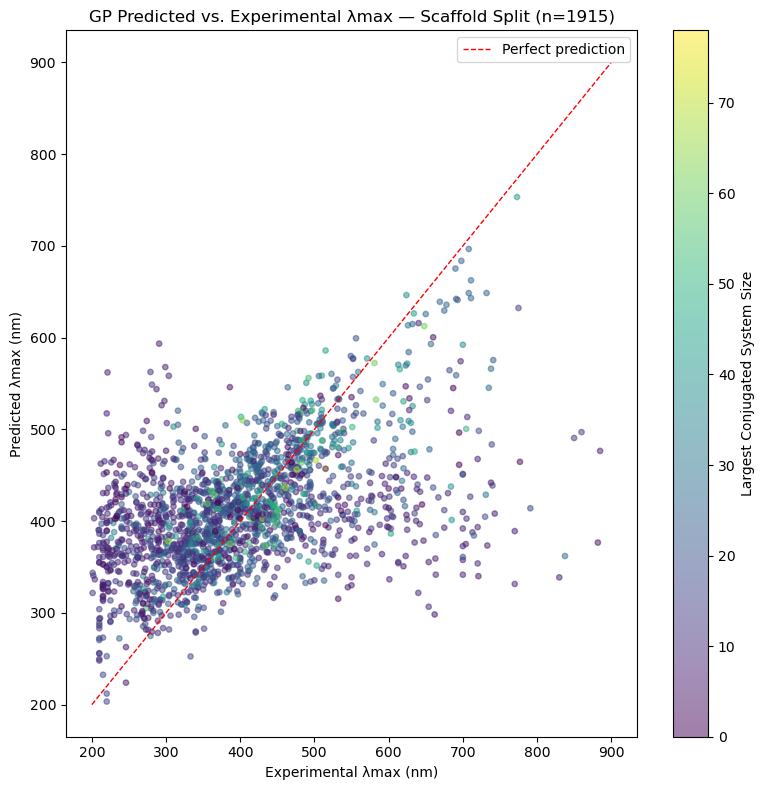

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sc = plt.scatter(
    y_test_scaf, y_pred_scaf,
    c=X_test_scaf["LargestConjugatedSystemSize"], cmap="viridis",
    alpha=0.5, s=15
)
plt.plot([200, 900], [200, 900], "r--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title(f"GP Predicted vs. Experimental λmax — Scaffold Split (n={len(y_test_scaf)})")
plt.colorbar(sc, label="Largest Conjugated System Size")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_vs_true_lambda_max_SCAFFOLD.png", dpi=300)
plt.show()

**GP vs. TD-DFT, scaffold-consistent benchmark (n=28)**

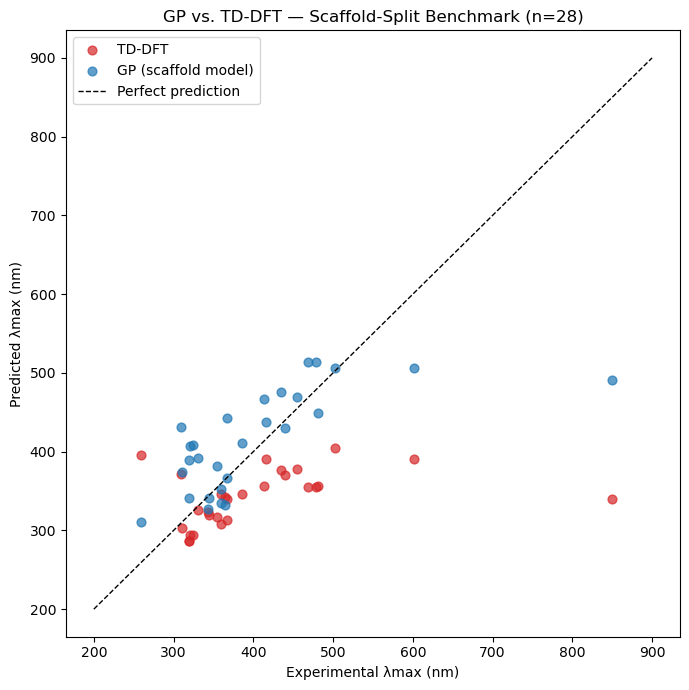

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_tddft_scaf, df_tddft_aligned["lambda1_TDDFT_nm"].values,
            color="tab:red", alpha=0.7, s=40, label="TD-DFT")
plt.scatter(y_true_tddft_scaf, y_pred_tddft_scaf_gp,
            color="tab:blue", alpha=0.7, s=40, label="GP (scaffold model)")
plt.plot([200, 900], [200, 900], "k--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title(f"GP vs. TD-DFT — Scaffold-Split Benchmark (n={len(y_true_tddft_scaf)})")
plt.legend()
plt.tight_layout()
plt.savefig("gp_vs_tddft_benchmark_SCAFFOLD.png", dpi=300)
plt.show()

**GP vs. sTDA, scaffold-consistent benchmark (n=1,477)**

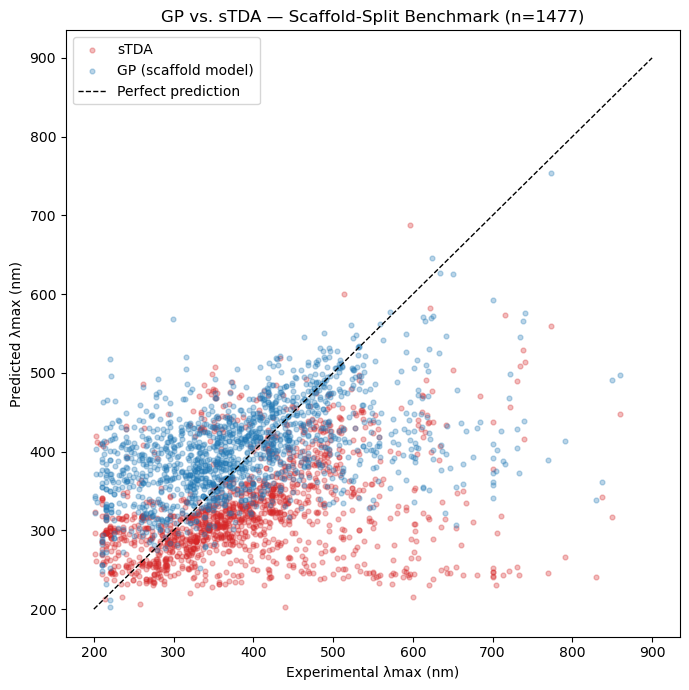

In [20]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_stda_scaf, df_stda_aligned2["lambda1_sTDA_nm"].values,
            color="tab:red", alpha=0.3, s=12, label="sTDA")
plt.scatter(y_true_stda_scaf, y_pred_stda_scaf_gp,
            color="tab:blue", alpha=0.3, s=12, label="GP (scaffold model)")
plt.plot([200, 900], [200, 900], "k--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title(f"GP vs. sTDA — Scaffold-Split Benchmark (n={len(y_true_stda_scaf)})")
plt.legend()
plt.tight_layout()
plt.savefig("gp_vs_stda_benchmark_SCAFFOLD.png", dpi=300)
plt.show()